# LOAD LIBRARIES

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    learn_gap_dist,
    create_artificial_gap_splits,
    plot_cv_splits
)

# CONFIGURATION

In [11]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'NEE'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True

# LOAD DATA

In [12]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.213 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 14928 of 14928 records (2023-10-17 00:15:00 to 2024-08-22 23:45:00, timestamp=middle)

Using data from 2023-10-17 00:00:00 to 2024-08-23 00:00:00

Target column: NEE_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,0
2023-10-17 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,1
2023-10-17 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.566667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,2
2023-10-17 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.266667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,3
2023-10-17 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.400000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,2.48319,0.0,0.0,15.870000,0.0,0.0,...,-0.926389,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.0,14923
2024-08-22 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.96792,0.0,0.0,15.160000,0.0,0.0,...,-0.895817,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.0,14924
2024-08-22 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,3.14515,0.0,0.0,15.100000,0.0,0.0,...,-0.886399,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.0,14925


# CLEAN DATA

In [13]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Filtered parcel_certainty=='certain': 5715/6564 rows kept


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,0.870527,0.870527,0.870527,0.870527,0.870527,0.870527,A,certain,0.0,0.181704,508.623,0.238,3.166667,101.126751,49.333333,...,0.083135,0.540118,-0.842504,-0.102048,2.532650,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,0.592505,1750
2023-11-22 11:45:00,0.844507,0.844507,0.844507,0.844507,0.844507,0.844507,A,certain,0.0,0.059309,531.452,0.000,3.043333,78.680983,38.666667,...,0.437046,0.910190,-0.702373,-1.077886,1.500116,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,0.593197,1751
2023-11-22 12:15:00,0.629330,0.629330,0.629330,0.629330,0.629330,0.629330,A,certain,0.0,0.066009,539.106,0.000,3.056667,82.889564,40.666667,...,0.298847,0.848023,-1.397743,-1.447180,1.126409,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,0.593890,1752
2023-11-22 12:45:00,0.602554,0.602554,0.602554,0.602554,0.602554,0.602554,A,certain,0.0,0.051177,531.452,0.000,3.000000,99.022460,48.333333,...,0.109385,0.461868,-0.930396,-0.980010,1.349691,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,0.594582,1753
2023-11-22 13:15:00,0.477717,0.477717,0.477717,0.477717,0.477717,0.477717,A,certain,0.0,0.112857,508.623,0.000,2.946667,117.961078,57.333333,...,0.494419,1.036708,-0.733805,-1.036927,0.366376,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,0.595275,1754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 14:45:00,7.660107,7.660107,7.660107,7.660107,7.660107,7.660107,A,certain,0.0,3.552050,905.835,0.000,23.103333,1492.280787,744.993580,...,-0.871593,-1.428149,-0.217355,-0.290252,-0.397630,187.067460,187.379274,184.373050,0.120233,188.0,1.0,30.0,1.0,0.000000,14909
2024-08-22 15:15:00,12.252563,12.252563,12.252563,12.252563,12.252563,12.252563,B,certain,1.0,1.624690,829.238,0.000,24.313333,1470.588387,744.041813,...,-0.909366,-1.494919,-0.272192,-0.318445,-0.411587,186.880952,187.373056,183.656100,0.247123,188.0,1.0,30.0,1.0,0.000000,14910
2024-08-22 15:45:00,8.197114,8.197114,8.197114,8.197114,8.197114,8.197114,B,certain,1.0,0.551227,741.895,0.000,24.536667,1322.432487,671.122436,...,-0.936038,-1.467906,-0.339830,-0.338404,-0.407802,186.694444,187.366777,182.941939,0.447626,188.0,1.0,30.0,1.0,0.000000,14911


# SELECT FEATURES

In [14]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 5715/5715


,SW_IN_POT,ppfd,sw_in,vpd,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,ta_lag3h,ts_0.05_gfXG_lag3h,ts_0.05_gfXG_lag6h,ts_0.05_gfXG_lag9h,ts_0.15_gfXG_lag3h,...,ts_0.05_gfXG_diff12h,ts_0.15_gfXG_diff6h,ts_0.3_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,id,trt,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,508.623,101.126751,49.333333,0.034392,3.804270,3.917853,56.445058,46.329025,35.0,60.0,5.140000,3.860598,3.967004,3.976688,3.930896,...,-1.577594,-0.235892,-0.219656,0.212969,0.540118,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,1750,0.0,0.870527
2023-11-22 11:45:00,531.452,78.680983,38.666667,0.035892,3.728857,3.886209,56.868153,45.774542,35.0,60.0,5.120000,3.830381,3.987376,3.927646,3.926520,...,-1.565632,-0.305857,-0.224241,0.628731,0.910190,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,1751,0.0,0.844507
2023-11-22 12:15:00,539.106,82.889564,40.666667,0.039047,3.714029,3.889060,56.839848,45.350239,35.0,60.0,4.883333,3.593132,4.063908,4.113959,3.899359,...,-2.841491,-0.178194,0.118752,0.554564,0.848023,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,1752,0.0,0.629330
2023-11-22 12:45:00,531.452,99.022460,48.333333,0.047355,3.841830,3.950730,56.476135,45.571171,36.0,60.0,4.460000,3.364207,4.041970,4.135447,3.868472,...,-2.927476,-0.079243,0.175203,1.485849,0.461868,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,1753,0.0,0.602554
2023-11-22 13:15:00,508.623,117.961078,57.333333,0.048761,3.930150,3.922793,56.817530,45.513794,36.0,60.0,4.213333,2.493631,3.930413,3.933636,3.690577,...,-2.741127,0.006175,0.182692,1.441885,1.036708,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,1754,0.0,0.477717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 14:45:00,905.835,1492.280787,744.993580,1.004917,20.372222,19.119630,43.804128,42.169136,1.0,29.0,19.276667,19.508148,16.790740,16.569630,18.781852,...,6.311482,1.972222,-0.762221,-3.937213,-1.428149,187.067460,187.379274,184.373050,0.120233,188.0,1.0,30.0,14909,0.0,7.660107
2024-08-22 15:15:00,829.238,1470.588387,744.041813,1.299229,20.632593,19.200000,43.719702,42.136662,1.0,29.0,20.273333,20.283333,16.978148,16.479630,18.973704,...,6.911112,2.232593,-0.611851,-3.982961,-1.494919,186.880952,187.373056,183.656100,0.247123,188.0,1.0,30.0,14910,1.0,12.252563
2024-08-22 15:45:00,741.895,1322.432487,671.122436,1.442002,20.870000,19.238148,43.678179,42.112901,1.0,29.0,21.663333,21.328518,17.231111,16.454441,19.169259,...,7.311849,2.470000,-0.533332,-4.001665,-1.467906,186.694444,187.366777,182.941939,0.447626,188.0,1.0,30.0,14911,1.0,8.197114


# IMBALANCE HANDLING

## UNDER SAMPLING

In [15]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [16]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

Log transform not applied.


# CROSS-VAL SPLITS

  Gap distribution: fitted mixture (cvm distance 0.5285; raw baseline 8.8917)
CV Strategy: artificial gaps in real time; 10 splits; test fractions 0.097-0.105
  Coverage: 1947/5715 rows never held out (34.1%); mean times held out 1.01


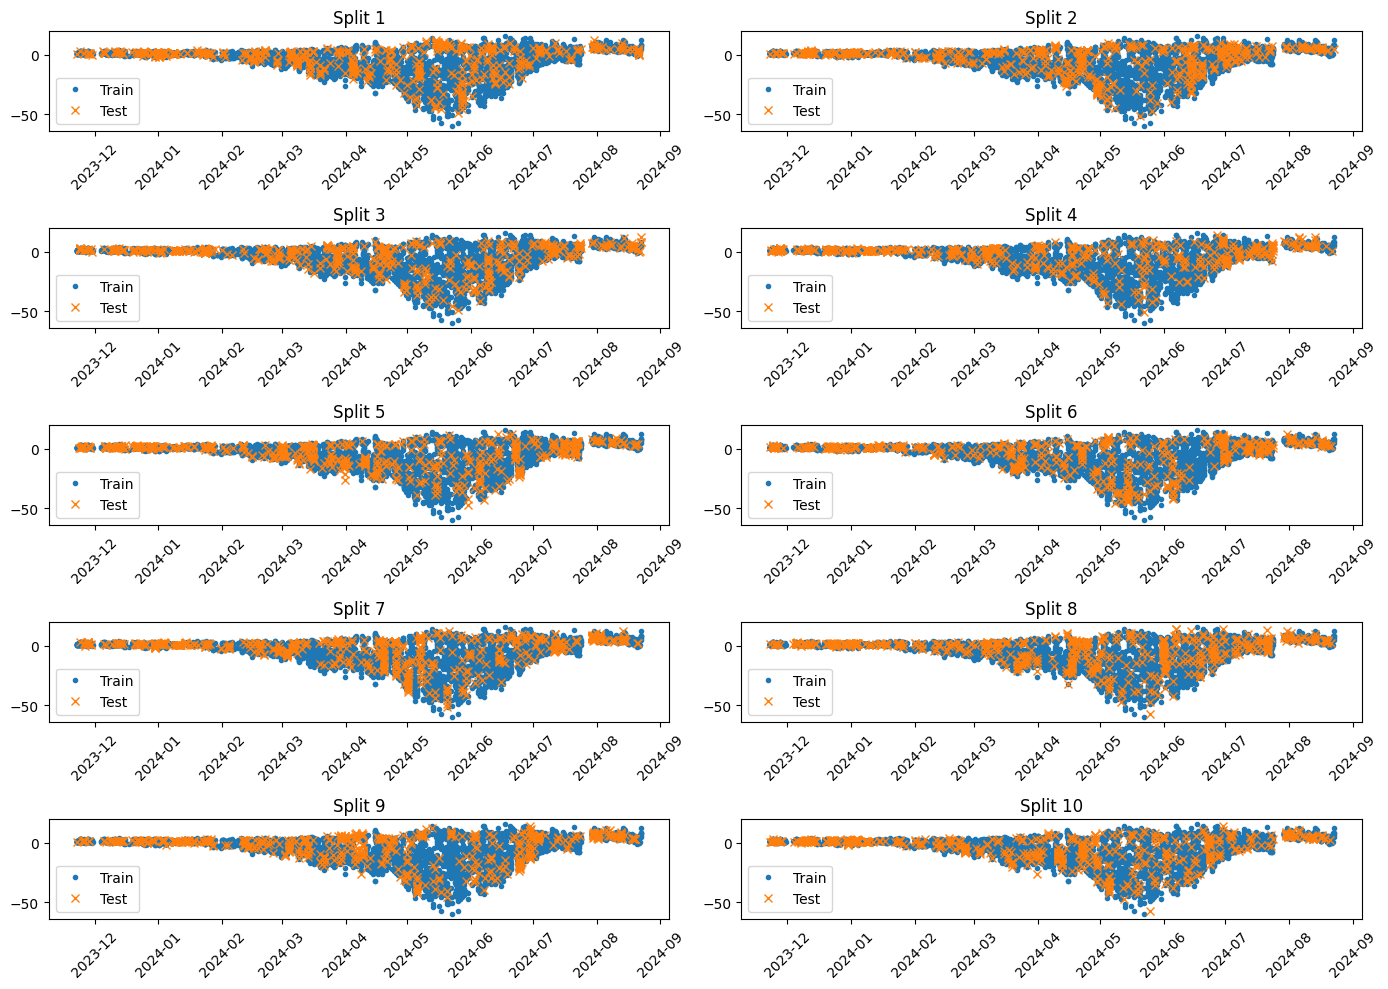

In [17]:
# Artificial-gap CV splits (Irvin et al. 2021 style)
rng = np.random.default_rng(42)

sampling_pmf = learn_gap_dist(data_main[TARGET], n_grid=6, n_mc=20, rng=rng, verbose=True)

splits, coverage = create_artificial_gap_splits(
    target_full=data_main[TARGET],   # full series, real NaNs intact -- NOT X/y
    train_index=X.index,
    sampling_pmf=sampling_pmf,
    n_splits=N_FOLDS,
    eval_frac=0.1,
    rng=rng,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [18]:
# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,      # number of random tries
    cv=splits,       # list of (train_idx, test_idx) 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best RMSE: 1.7747
Best Params: {'colsample_bytree': np.float64(0.9844762255295657), 'gamma': np.float64(0.45267532097803187), 'learning_rate': np.float64(0.024579113478929646), 'max_depth': 14, 'min_child_weight': 2, 'n_estimators': 352, 'subsample': np.float64(0.6377771843023713)}


# EXPORT 

In [19]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [20]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-09-17 19:03:21
